In [1]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math
import pickle

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

import statsmodels.api as sm
import pmdarima as pm


# Forcing Fitting Extension

In [2]:
with open("/glade/work/stevenxu/FAIR_models/origional_model_extension.pkl", "rb") as f_in:
    f1 = pickle.load(f_in)

#with open("/glade/work/stevenxu/FAIR_models/top10_model_extension.pkl", "rb") as f_in:
 #   f2 = pickle.load(f_in)

#with open("/glade/work/stevenxu/FAIR_models/top20_model_extension.pkl", "rb") as f_in:
 #   f3 = pickle.load(f_in)

## Finding the year when data diverges by scenarios
2024

In [5]:
for specie in f1.species:
    config = f1.configs[0]  # taking first config
    da = f1.forcing.sel(config=config, specie=specie)
    spread = da.max(dim="scenario") - da.min(dim="scenario")

    # Find the first year when spread is strictly greater than zero
    different_mask = spread > 0
    if different_mask.any():
        first_idx = int(np.argmax(different_mask.values))  # index of first True
        year_start_diff = int(spread["timebounds"].values[first_idx])
        print(specie, ': ' , year_start_diff)
    else:
        print(specie, ': ' , "never diverges")

CO2 FFI :  never diverges
CO2 AFOLU :  never diverges
CO2 :  2024
CH4 :  2024
N2O :  2024
Sulfur :  never diverges
BC :  never diverges
OC :  never diverges
NH3 :  never diverges
NOx :  never diverges
VOC :  never diverges
CO :  never diverges
CFC-11 :  never diverges
CFC-12 :  never diverges
CFC-113 :  never diverges
CFC-114 :  never diverges
CFC-115 :  never diverges
HCFC-22 :  never diverges
HCFC-141b :  never diverges
HCFC-142b :  never diverges
CCl4 :  never diverges
CHCl3 :  2024
CH2Cl2 :  2024
CH3Cl :  2024
CH3CCl3 :  never diverges
CH3Br :  2024
Halon-1211 :  never diverges
Halon-1301 :  never diverges
Halon-2402 :  never diverges
CF4 :  2024
C2F6 :  2024
C3F8 :  2024
c-C4F8 :  2024
C4F10 :  2024
C5F12 :  2024
C6F14 :  2024
C7F16 :  2024
C8F18 :  2024
NF3 :  2024
SF6 :  2024
SO2F2 :  2024
HFC-125 :  2024
HFC-134a :  2024
HFC-143a :  2024
HFC-152a :  2024
HFC-227ea :  2024
HFC-23 :  2024
HFC-236fa :  2024
HFC-245fa :  2024
HFC-32 :  2024
HFC-365mfc :  2024
HFC-4310mee :  2024
So

In [7]:
no_forcing_species = []
for specie in f1.species:
    da = f1.forcing.sel(scenario = f1.scenarios[0], specie=specie).mean(dim="config")
    if da.sum() == 0:
        no_forcing_species.append(specie)

no_forcing_species

['CO2 FFI',
 'CO2 AFOLU',
 'Sulfur',
 'BC',
 'OC',
 'NH3',
 'NOx',
 'VOC',
 'CO',
 'Equivalent effective stratospheric chlorine']

## Arima Fitting for each specie

In [ ]:
org_specie = f1.species
species_with_forcing = [s for s in org_specie if s not in no_forcing_species]
arima_list = {}
count = 0

for specie in species_with_forcing:
    count += 1
    print("Fitting ARIMA for ", specie, " ", count, "/", len(species_with_forcing))
    da = f1.forcing.sel(scenario = f1.scenarios[5], specie=specie, timebounds = slice(None, 2024)).mean(dim="config")
    model = pm.auto_arima(da.values, start_p=1, start_q=1,
                                max_p=3, max_q=3, m=12,
                                start_P=0, seasonal=True,
                                d=1, D=1, trace=True,
                                error_action='ignore',  # don't want to know if an order does not work
                                suppress_warnings=True,  # don't want convergence warnings
                                stepwise=True)  # set to stepwise
    arima_list[specie] = model

arima_list


In [ ]:
save_path = "/glade/work/stevenxu/FAIR_models/arima_list_forcing_extension.pkl"
with open(save_path, "wb") as f:
    pickle.dump(arima_list, f)

# Emission Fitting Extension

## Finding the year when data diverges by scenarios
2023

In [3]:
for specie in f1.species:
    config = f1.configs[0]  # taking first config
    da = f1.emissions.sel(config=config, specie=specie)
    spread = da.max(dim="scenario") - da.min(dim="scenario")

    # Find the first year when spread is strictly greater than zero
    different_mask = spread > 0
    if different_mask.any():
        first_idx = int(np.argmax(different_mask.values))  # index of first True
        year_start_diff = int(spread["timepoints"].values[first_idx])
        print(specie, ': ' , year_start_diff)
    else:
        print(specie, ': ' , "never diverges")

CO2 FFI :  2023
CO2 AFOLU :  2023
CO2 :  2023
CH4 :  2023
N2O :  2023
Sulfur :  2023
BC :  2023
OC :  2023
NH3 :  2023
NOx :  2023
VOC :  2023
CO :  2023
CFC-11 :  never diverges
CFC-12 :  never diverges
CFC-113 :  never diverges
CFC-114 :  never diverges
CFC-115 :  never diverges
HCFC-22 :  never diverges
HCFC-141b :  never diverges
HCFC-142b :  never diverges
CCl4 :  never diverges
CHCl3 :  2023
CH2Cl2 :  2023
CH3Cl :  2023
CH3CCl3 :  never diverges
CH3Br :  2023
Halon-1211 :  never diverges
Halon-1301 :  never diverges
Halon-2402 :  never diverges
CF4 :  2023
C2F6 :  2023
C3F8 :  2023
c-C4F8 :  2023
C4F10 :  2023
C5F12 :  2023
C6F14 :  2023
C7F16 :  2023
C8F18 :  2023
NF3 :  2023
SF6 :  2023
SO2F2 :  2023
HFC-125 :  2023
HFC-134a :  2023
HFC-143a :  2023
HFC-152a :  2023
HFC-227ea :  2023
HFC-23 :  2023
HFC-236fa :  2023
HFC-245fa :  2023
HFC-32 :  2023
HFC-365mfc :  2023
HFC-4310mee :  2023
Solar :  never diverges
Volcanic :  never diverges
Aerosol-radiation interactions :  never d

In [4]:
no_emission_species = []
for specie in f1.species:
    da = f1.emissions.sel(scenario = f1.scenarios[0], specie=specie).mean(dim="config")
    if da.sum() == 0:
        no_emission_species.append(specie)

no_emission_species

['Solar',
 'Volcanic',
 'Aerosol-radiation interactions',
 'Aerosol-cloud interactions',
 'Ozone',
 'Light absorbing particles on snow and ice',
 'Stratospheric water vapour',
 'Land use',
 'Equivalent effective stratospheric chlorine']

## Arima Fitting for each specie

In [5]:
org_specie = f1.species
species_with_emissions = [s for s in org_specie if s not in no_emission_species]
arima_list = {}
count = 0

for specie in species_with_emissions:
    count += 1
    print("Fitting ARIMA for ", specie, " ", count, "/", len(species_with_emissions))
    da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2023)).mean(dim="config")
    model = pm.auto_arima(da.values, start_p=1, start_q=1,
                                max_p=3, max_q=3, m=12,
                                start_P=0, seasonal=True,
                                d=1, D=1, trace=True,
                                error_action='ignore',  # don't want to know if an order does not work
                                suppress_warnings=True,  # don't want convergence warnings
                                stepwise=True)  # set to stepwise
    arima_list[specie] = model

arima_list


Fitting ARIMA for  CO2 FFI   1 / 52
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=2.70 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=291.439, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=239.434, Time=0.26 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=203.980, Time=0.61 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=293.324, Time=0.08 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=204.138, Time=0.82 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=203.028, Time=1.05 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=202.737, Time=2.66 sec
 ARIMA(0,1,1)(2,1,2)[12]             : AIC=201.517, Time=3.05 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=202.265, Time=1.19 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=200.729, Time=2.24 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=202.738, Time=2.98 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=201.647, Time=0.93 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=204.660, Time=0.54 sec
 

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1905: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(1,1,0)(1,1,2)[12]             : AIC=-1676.919, Time=0.67 sec
 ARIMA(1,1,0)(0,1,2)[12]             : AIC=-1786.485, Time=7.85 sec
 ARIMA(1,1,0)(2,1,2)[12]             : AIC=-1778.526, Time=4.68 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=2.73 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=-1787.680, Time=3.44 sec
 ARIMA(2,1,0)(0,1,1)[12]             : AIC=inf, Time=4.70 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=-1718.619, Time=1.54 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=-1778.779, Time=4.60 sec
 ARIMA(2,1,0)(1,1,2)[12]             : AIC=inf, Time=10.44 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=-1608.994, Time=0.41 sec
 ARIMA(2,1,0)(0,1,2)[12]             : AIC=-1786.479, Time=2.93 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-1760.395, Time=2.16 sec
 ARIMA(2,1,0)(2,1,2)[12]             : AIC=-1768.599, Time=5.30 sec
 ARIMA(3,1,0)(1,1,1)[12]             : AIC=-1788.595, Time=3.96 sec
 ARIMA(3,1,0)(0,1,1)[12]             : AIC=inf, Time=4.24 sec
 AR

{'CO2 FFI': ARIMA(order=(0, 1, 0), scoring_args={}, seasonal_order=(2, 1, 2, 12),
       suppress_warnings=True, with_intercept=False),
 'CO2 AFOLU': ARIMA(order=(0, 1, 0), scoring_args={}, seasonal_order=(2, 1, 0, 12),
       suppress_warnings=True, with_intercept=False),
 'CO2': ARIMA(order=(0, 1, 0), scoring_args={}, seasonal_order=(1, 1, 1, 12),
       suppress_warnings=True, with_intercept=False),
 'CH4': ARIMA(order=(1, 1, 2), scoring_args={}, seasonal_order=(1, 1, 1, 12),
       suppress_warnings=True, with_intercept=False),
 'N2O': ARIMA(order=(0, 1, 0), scoring_args={}, seasonal_order=(0, 1, 1, 12),
       suppress_warnings=True, with_intercept=False),
 'Sulfur': ARIMA(order=(3, 1, 3), scoring_args={}, seasonal_order=(2, 1, 0, 12),
       suppress_warnings=True, with_intercept=False),
 'BC': ARIMA(order=(2, 1, 2), scoring_args={}, seasonal_order=(0, 1, 1, 12),
       suppress_warnings=True, with_intercept=False),
 'OC': ARIMA(order=(2, 1, 3), scoring_args={}, seasonal_order=(0

In [6]:
save_path = "/glade/work/stevenxu/FAIR_models/arima_list_emission_extension.pkl"
with open(save_path, "wb") as f:
    pickle.dump(arima_list, f)

# Special

## Turn off Seasonal Trend

In [3]:
with open("/glade/work/stevenxu/FAIR_models/arima_list_emission_extension.pkl", "rb") as f:
    arima_list = pickle.load(f)

In [8]:
def forecast_plotting(specie, model, startyear=2015, endyear=2300):
	scenario_for_forecast = f1.scenarios[5]

	fig, ax = pl.subplots(figsize=(8,5))

	# historical
	da_hist = (
		f1.emissions
		.sel(specie=specie, scenario=scenario_for_forecast, timepoints=slice(None, startyear))
		.mean(dim="config")
	)
	ax.plot(da_hist["timepoints"].values, da_hist.values,
			linewidth=2.5, color="k", label=f"historical")

	#prediction
	n_steps = endyear - startyear
	ffl_fc, ffl_conf_int = model.predict(n_periods=n_steps, return_conf_int=True)
	future_years = np.arange(startyear + 1, endyear + 1)
	ax.plot(future_years, ffl_fc, linewidth=2, color="black", linestyle="--", label="ARIMA forecast")

	# CI interval
	ax.fill_between(future_years, ffl_conf_int[:,0], ffl_conf_int[:,1],
					alpha=0.2, label="95% CI")

	# plot scenarios
	for scen in f1.scenarios:
		da_all = (
			f1.emissions
			.sel(specie=specie, scenario=scen, timepoints=slice(startyear-1, endyear))
			.mean(dim="config")
		)
		ax.plot(da_all["timepoints"].values, da_all.values, label=str(scen))

	# views
	ax.axvline(startyear, color="k", linestyle=":", alpha=0.6)
	ax.set_xlabel("Year")
	ax.set_ylabel("Emission (Mt/yr)")
	ax.set_title(f"ARIMA Forecast of {specie} Emission")
	ax.legend(loc="best", ncol=1, frameon=True)
	pl.show()


### Sulfur

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1211.034, Time=0.70 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1247.172, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1212.046, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1212.974, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1248.762, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.17 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1203.215, Time=0.57 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1214.712, Time=0.22 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1202.347, Time=0.72 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=1203.070, Time=1.21 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1203.691, Time=0.97 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1201.775, Time=0.57 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1210.343, Time=0.31 sec
 ARIMA(1,1,3)(0,0,0)[0]             : AIC=1199.906, Time=0.16 sec
 ARIMA(0,1,3)(0,0,0)[0]             : 

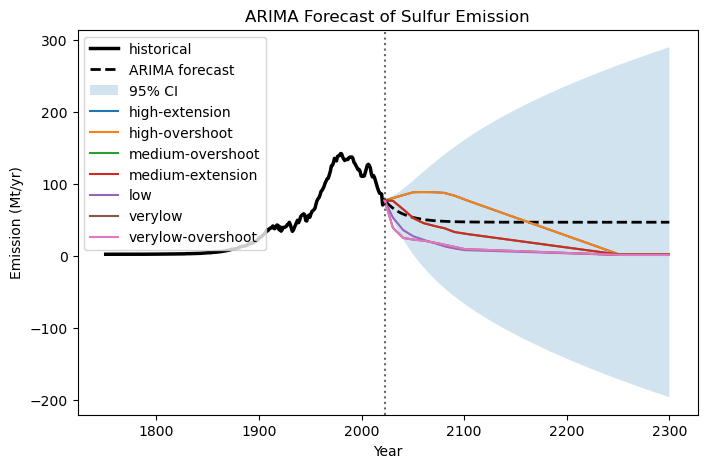

In [10]:
specie = "Sulfur"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2023)).mean(dim="config")
model = pm.auto_arima(da.values, start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0,  seasonal=False,
							d=1, D=0, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
forecast_plotting(specie, model, startyear=2023, endyear=2300)

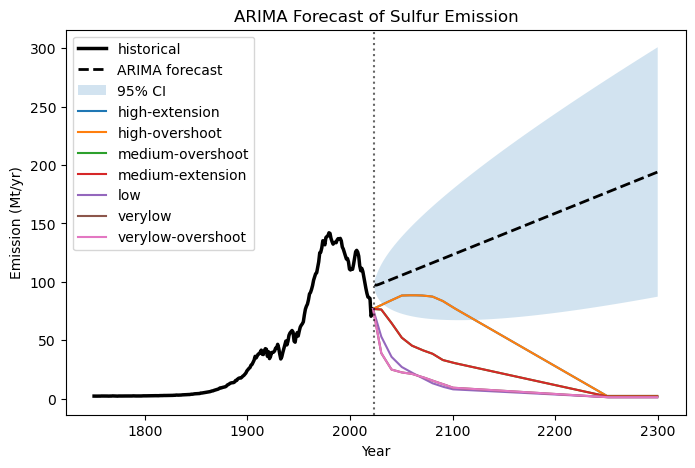

In [9]:
forecast_plotting(specie, model, startyear=2023, endyear=2300)

### CFC-11

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.78 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1985.482, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1621.435, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1983.624, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1579.319, Time=0.19 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=1580.188, Time=0.27 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.94 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.23 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1577.325, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1619.446, Time=0.03 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=1578.191, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=inf, Time=0.60 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=inf, Time=0.42 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=inf, Time=0.89 sec

B

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1420: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


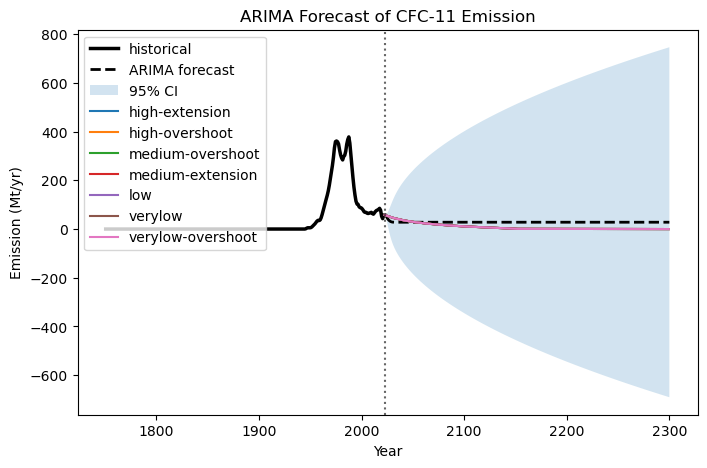

In [11]:
specie = "CFC-11"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2023)).mean(dim="config")
model = pm.auto_arima(da.values, start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0,  seasonal=False,
							d=1, D=0, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
forecast_plotting(specie, model, startyear=2023, endyear=2300)

### CFC-12

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1782.470, Time=0.27 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2135.444, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1887.233, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1852.721, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2133.464, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1780.493, Time=0.43 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1860.092, Time=0.20 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1780.708, Time=0.71 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1781.186, Time=0.93 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1779.351, Time=0.30 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1802.800, Time=0.38 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1781.144, Time=0.55 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1792.718, Time=0.45 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1782.399, Time=0.96 sec
 ARIMA(1,1,2)(0,0,0)[0]          

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1420: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


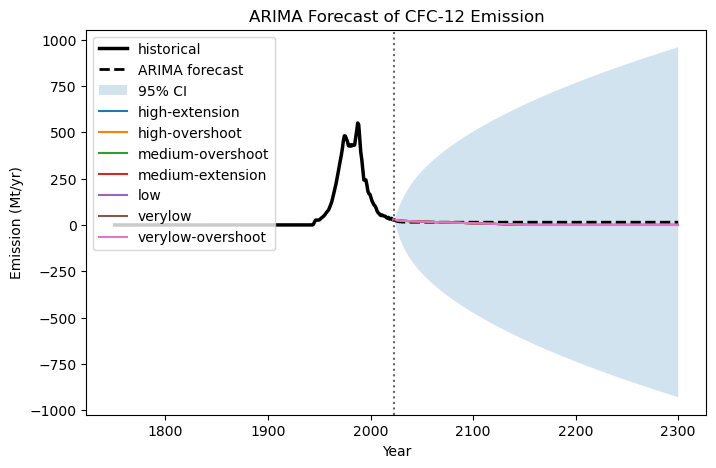

In [12]:
specie = "CFC-12"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2023)).mean(dim="config")
model = pm.auto_arima(da.values, start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0,  seasonal=False,
							d=1, D=0, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
forecast_plotting(specie, model, startyear=2023, endyear=2300)

## Log method

In [3]:
with open("/glade/work/stevenxu/FAIR_models/arima_list_emission_extension.pkl", "rb") as f:
    arima_list = pickle.load(f)

In [14]:
def forecast_plotting(specie, model, startyear=2015, endyear=2300):
	scenario_for_forecast = f1.scenarios[5]

	fig, ax = pl.subplots(figsize=(8,5))

	# historical
	da_hist = (
		f1.emissions
		.sel(specie=specie, scenario=scenario_for_forecast, timepoints=slice(None, startyear))
		.mean(dim="config")
	)
	ax.plot(da_hist["timepoints"].values, da_hist.values,
			linewidth=2.5, color="k", label=f"historical")

	#prediction
	n_steps = endyear - startyear
	ffl_fc, ffl_conf_int = model.predict(n_periods=n_steps, return_conf_int=True)

	ffl_fc = np.expm1(ffl_fc)
	ffl_conf_int = np.expm1(ffl_conf_int)

	future_years = np.arange(startyear + 1, endyear + 1)
	ax.plot(future_years, ffl_fc, linewidth=2, color="black", linestyle="--", label="ARIMA forecast")

	# CI interval
	#ax.fill_between(future_years, ffl_conf_int[:,0], ffl_conf_int[:,1],
	#				alpha=0.2, label="95% CI")

	# plot scenarios
	for scen in f1.scenarios:
		da_all = (
			f1.emissions
			.sel(specie=specie, scenario=scen, timepoints=slice(startyear-1, endyear))
			.mean(dim="config")
		)
		ax.plot(da_all["timepoints"].values, da_all.values, label=str(scen))

	# views
	ax.axvline(startyear, color="k", linestyle=":", alpha=0.6)
	ax.set_xlabel("Year")
	ax.set_ylabel("Emission (Mt/yr)")
	ax.set_title(f"ARIMA Forecast of {specie} Emission")
	ax.legend(loc="best", ncol=1, frameon=True)
	pl.show()


### Sulfur

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=3.16 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-791.266, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-870.428, Time=0.36 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.17 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-790.024, Time=0.05 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-886.256, Time=0.97 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.46 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=1.94 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-883.643, Time=0.70 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-884.307, Time=1.27 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=-888.385, Time=1.85 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=-867.625, Time=0.47 sec
 ARIMA(1,1,1)(2,1,1)[12]             : AIC=inf, Time=3.51 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=inf, Time=2.04 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=-886.1

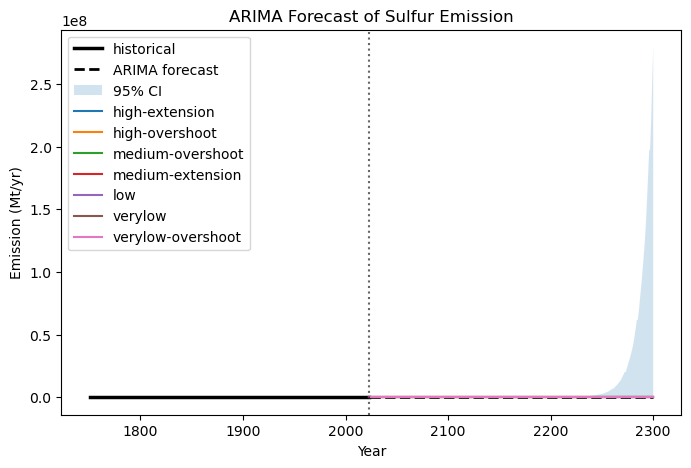

In [ ]:
specie = "Sulfur"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2023)).mean(dim="config")
model = pm.auto_arima(np.log1p(da.values), start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0, m=12, seasonal=True,
							d=1, D=1, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
forecast_plotting(specie, model, startyear=2023, endyear=2300)

### CFC-11

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=2.96 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-340.934, Time=0.13 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-542.309, Time=0.40 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=2.49 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-483.781, Time=0.09 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-572.128, Time=1.22 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=3.83 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=1.57 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-385.674, Time=0.36 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-611.092, Time=1.13 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=-589.342, Time=0.60 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=inf, Time=2.58 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=1.89 sec
 ARIMA(3,1,0)(2,1,0)[12]             : AIC=-676.655, Time=2.69 sec
 ARIMA(3,1,0)(1,1,0)[12]             : AIC=-645.8

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1420: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


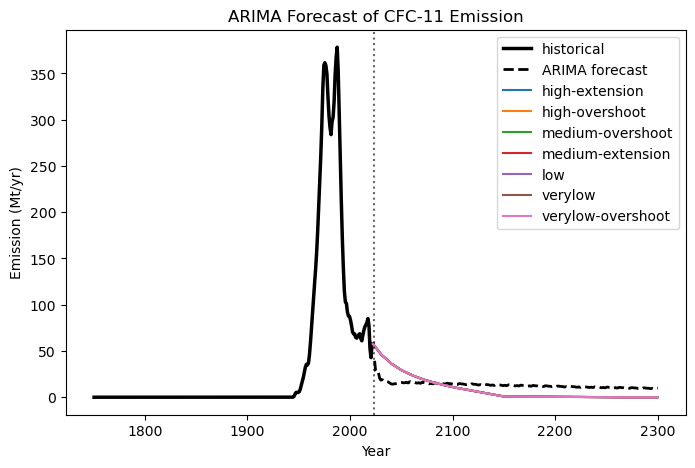

In [9]:
specie = "CFC-11"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2023)).mean(dim="config")
model = pm.auto_arima(np.log1p(da.values), start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0, m=12, seasonal=True,
							d=1, D=1, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
forecast_plotting(specie, model, startyear=2023, endyear=2300)

### CFC-12

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=1.94 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-166.870, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-346.522, Time=0.22 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.13 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-291.265, Time=0.16 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-365.266, Time=0.83 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=3.09 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=1.43 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-231.065, Time=0.37 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-387.237, Time=1.09 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=-373.324, Time=0.36 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=inf, Time=3.89 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=2.12 sec
 ARIMA(3,1,0)(2,1,0)[12]             : AIC=-391.619, Time=1.73 sec
 ARIMA(3,1,0)(1,1,0)[12]             : AIC=-376.3

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1420: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


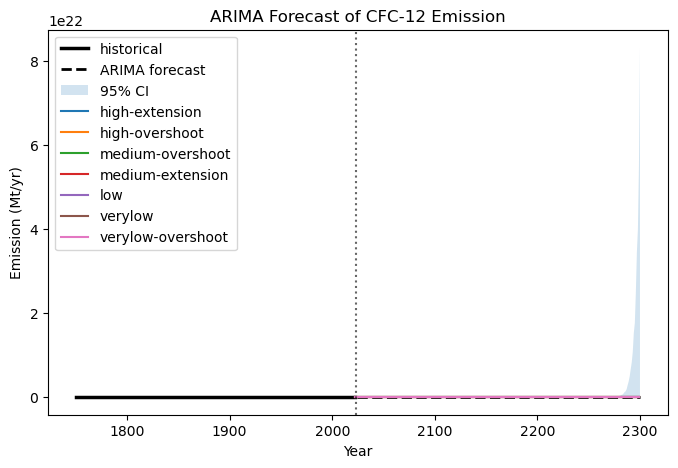

In [12]:
specie = "CFC-12"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2023)).mean(dim="config")
model = pm.auto_arima(np.log1p(da.values), start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0, m=12, seasonal=True,
							d=1, D=1, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
forecast_plotting(specie, model, startyear=2023, endyear=2300)

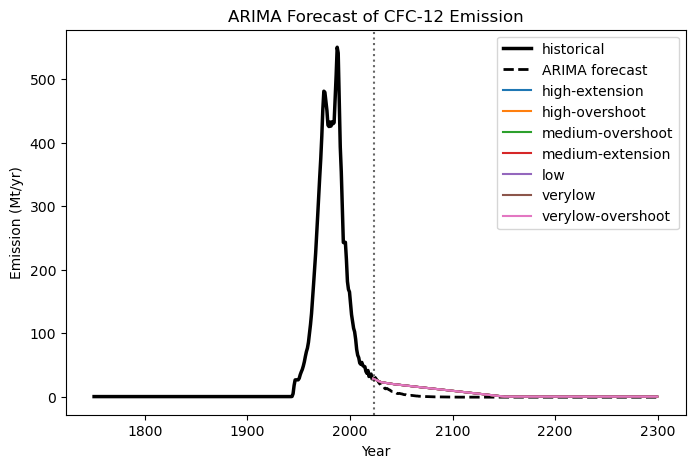

In [15]:
forecast_plotting(specie, model, startyear=2023, endyear=2300)